# Durables vs Non Durables At Low And High Frequencies

In this notebook, **real** is shorthand for **deflated by the broad PCE price index**: nominal spending on durable and on nondurable goods ([PCDG](https://fred.stlouisfed.org/series/PCDG) and [PCND](https://fred.stlouisfed.org/series/PCND) on FRED), each divided by the same index, the price index for all of personal consumption expenditures, [PCECTPI](https://fred.stlouisfed.org/series/PCECTPI). It does not mean BEA's "real" spending in chained dollars ([PCDGCC96](https://fred.stlouisfed.org/series/PCDGCC96) and [PCNDGC96](https://fred.stlouisfed.org/series/PCNDGC96)), which deflates each category by its own price index. Dividing both by the same index removes general inflation; unlike deflating each by its own price index, it leaves the ratio of the two series equal to the ratio of nominal spending on them. The notebook reads the data as saved by their last download, in the folder beside it, so every run gives the same results; the date of that download is in the saved file's name and is printed when the data are read. To use the current data instead, set `download = True` in the data cell: the notebook then fetches them from FRED and BEA and saves them as the copy later runs read.

An earlier version of this notebook used nominal spending, undeflated. Inflation raises both nominal series together, so much of their apparent co-movement, particularly in the 1970s, came from common inflation rather than from the relationship between spending on durables and nondurables that the theory is about.

In [1]:
# Some initial setup
from matplotlib import pyplot as plt
import numpy as np
plt.style.use('seaborn-v0_8-darkgrid')
import pandas as pd
import datetime
from pathlib import Path
import seaborn as sns

In [2]:
# Quarterly data from FRED, as saved by the last download in the folder beside this notebook.
# Set download = True to fetch the current data (here and from BEA below) and save them for later runs.
download = False
saved = Path('Durables-vs-Nondurables-At-Low-And-High-Frequencies')
if download or not any(saved.glob('fred-*.csv')):
    saved.mkdir(exist_ok=True)
    url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=PCDG,PCND,PCECTPI,PCESV'
    pd.read_csv(url, index_col=0).to_csv(saved / f'fred-PCDG-PCND-PCECTPI-PCESV-{datetime.date.today()}.csv')
fred_file = sorted(saved.glob('fred-*.csv'))[-1] # the latest download
fred = pd.read_csv(fred_file, index_col=0, parse_dates=True)

start = datetime.datetime(1947, 1, 1) #beginning of series
start1 = datetime.datetime(1956, 10, 1) #beginning of series

# Every quarter for which all three series are available, through the latest
data = fred[['PCDG', 'PCND', 'PCECTPI']].loc[start:].dropna()
end = data.index[-1] #end of series
print('FRED data downloaded', fred_file.stem[-10:] + ': from', data.index[0].date(), 'through', end.date())

# "Real" here means deflated by the broad PCE price index: each nominal series divided by PCECTPI,
# the price index for all of personal consumption, not by its own category's price index
real = data[['PCDG', 'PCND']].div(data['PCECTPI'], axis=0).set_axis(['Durables', 'Nondurables'], axis=1)

PCDG = real[['Durables']] #loads your durable goods quarterly series data
PCND = real[['Nondurables']] #Loads your non durable goods quarterly series data
PCDG1 = real.loc[start1:, ['Durables']] #loads your durable goods quarterly series data, helps in having time series of identical length
PCND1 = real.loc[start1:, ['Nondurables']] #Loads your non durable goods quarterly series data, , helps in having time series of identical length

FRED data downloaded 2026-10-05: from 1947-01-01 through 2026-04-01


In [3]:
# Constructing PCDG and PCND growth series () 
z1=PCDG.pct_change(periods=40)# 10*4
z2=PCND.pct_change(periods=40)#10*4
z3=PCDG1.pct_change(periods=1)# 
z4=PCND1.pct_change(periods=1)#
s1=z1*100 #(In percentage terms)
s2=z2*100 #(In percentage terms)
s3=z3*100 #(In percentage terms)
s4=z4*100 #(In percentage terms)

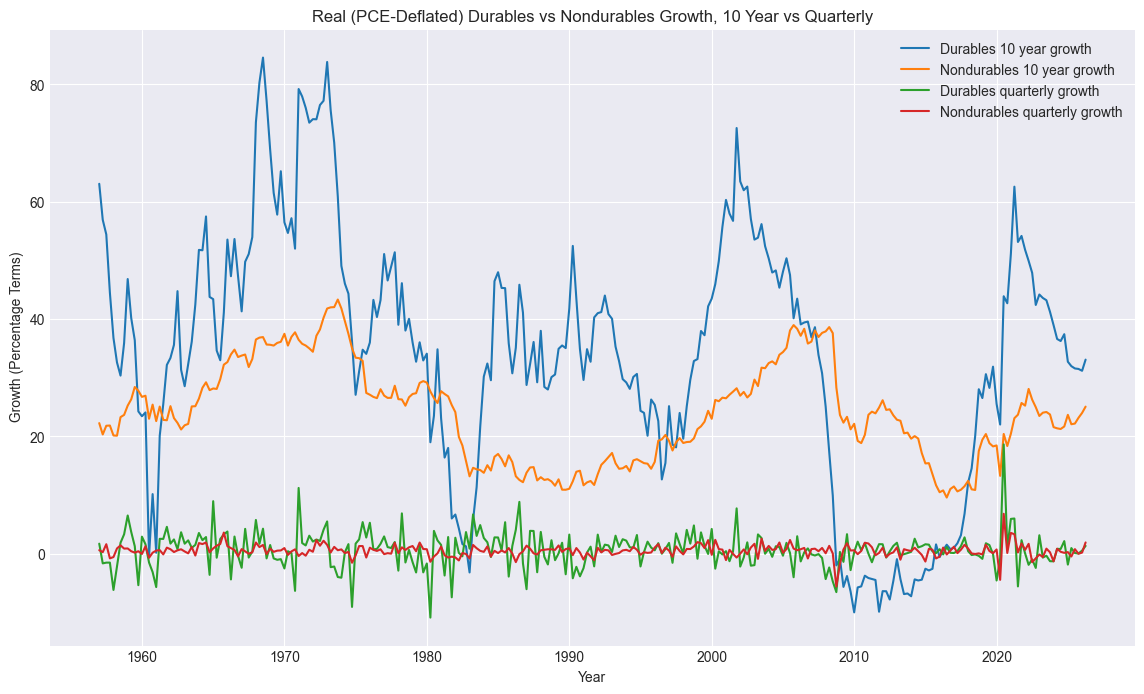

In [4]:
# Plotting the growth rates
plt.figure(figsize=((14,8))) # set the plot size
plt.title('Real (PCE-Deflated) Durables vs Nondurables Growth, 10 Year vs Quarterly')
plt.xlabel('Year')
plt.ylabel(' Growth (Percentage Terms)')
plt.plot(s1,label="Durables 10 year growth")
plt.plot(s2,label="Nondurables 10 year growth")
plt.plot(s3,label="Durables quarterly growth")
plt.plot(s4,label="Nondurables quarterly growth")
plt.legend()
plt.show()

In [5]:
# Drops the missing NAN observations

a1=s1.dropna()#Drops the missing values from s1 series
a2=s2.dropna()#Drops the missing values from s2 series
a3=s3.dropna()#Drops the missing values from s3 series
a4=s4.dropna()#Drops the missing values from s4 series

In [6]:
# concatate (merge) the two series
c1=pd.concat([a1, a2], axis=1)
c2=pd.concat([a3, a4], axis=1)

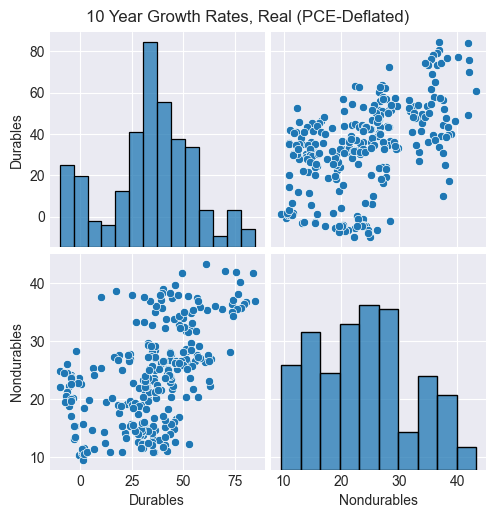

In [7]:
#Pairwise Plotting for the 10 year growth series

sns.pairplot(c1)
plt.suptitle('10 Year Growth Rates, Real (PCE-Deflated)', y=1.02)  # above the panels, which pairplot fills to the top
plt.show()

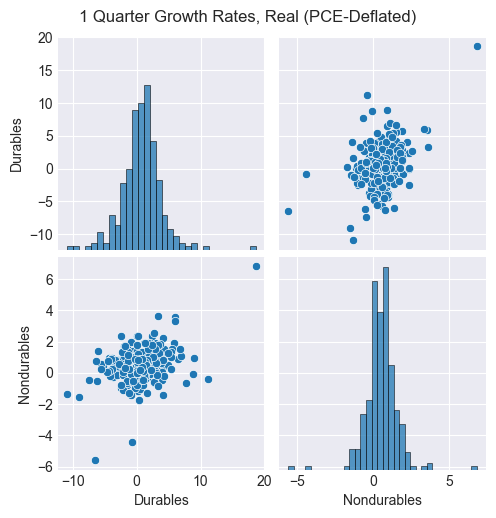

In [8]:
#Pairwise Plotting for the quarterly growth series

sns.pairplot(c2)
plt.suptitle('1 Quarter Growth Rates, Real (PCE-Deflated)', y=1.02)  # above the panels, which pairplot fills to the top
plt.show()

For each frequency [quarterly|10-year] each moment of time would correspond to a single point (x=nondurables growth, y=durables growth).  At both frequencies real (PCE-deflated) spending on durables is far more variable than real spending on nondurables, and the more so at the 1 quarter frequency.

## The Stock of Motor Vehicles

The model's prediction concerns the *stock* of durables, which the spending data above do not measure. For motor vehicles BEA publishes a stock built from the same spending data: line 2, "Motor vehicles and parts", of Table 8.1 in the [Fixed Assets Accounts](https://www.bea.gov/itable/fixed-assets), the current-cost net stock of consumer durable goods (annual, at yearend). BEA accumulates it from personal consumption expenditures on motor vehicles and parts, less the dealers' margins on used vehicles and the replacement parts, which add nothing to the stock ([BEA's reconciliation](https://www.bea.gov/sites/default/files/2017-05/CDGreconciliation.pdf)).

The figure divides the stock during each year (the average of the stocks at the end of that year and of the year before) by that year's spending on nondurables and services. Both are in current dollars. Because the stock is valued at current prices, the ratio also moves with vehicle prices: its rise after 2020 came from higher vehicle prices, not from more vehicles.

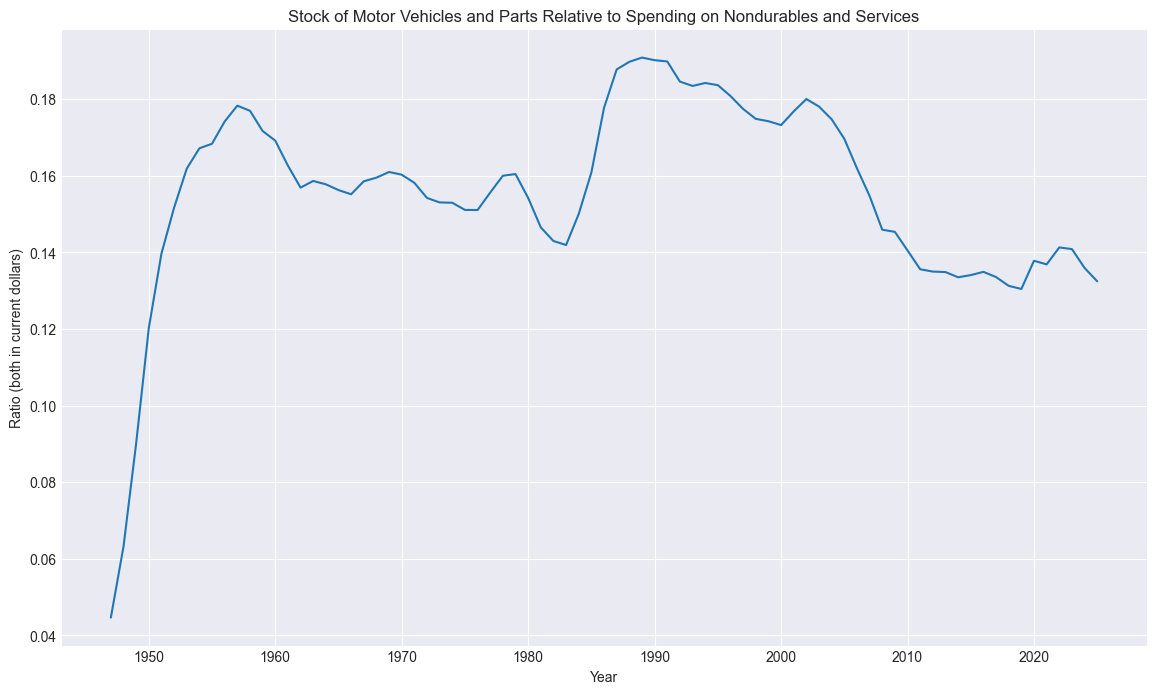

In [9]:
# BEA Fixed Assets Table 8.1, line 2: current-cost net stock of motor vehicles and parts,
# millions of dollars at yearend, as saved by the last download
if download or not any(saved.glob('bea-*.csv')):
    bea = pd.read_excel('https://apps.bea.gov/national/FixedAssets/Release/XLS/Section8All_xls.xlsx',
                        sheet_name='FAAt801-A', header=7, index_col=0)
    assert bea.loc['2'].iloc[0] == 'Motor vehicles and parts'
    years = [c for c in bea.columns if str(c).isdigit()]
    stock = bea.loc['2', years].astype(float).rename_axis('year').rename('stock')
    stock.to_csv(saved / f'bea-motor-vehicle-stock-{datetime.date.today()}.csv')
stock = pd.read_csv(sorted(saved.glob('bea-*.csv'))[-1], index_col='year')['stock']
stock = (stock + stock.shift(1)) / 2 # the stock during each year: average of this yearend and the last

# Spending on nondurables and services: annual average of the quarterly series, complete years only
NDS = fred['PCND'] + fred['PCESV'] # billions of dollars, annual rate
NDS = NDS.groupby(NDS.index.year).agg(['mean', 'count'])
NDS = NDS.loc[NDS['count'] == 4, 'mean'] * 1000 # millions of dollars, like the stock

ratio = (stock / NDS).dropna()
plt.figure(figsize=((14,8))) # set the plot size
plt.title('Stock of Motor Vehicles and Parts Relative to Spending on Nondurables and Services')
plt.xlabel('Year')
plt.ylabel('Ratio (both in current dollars)')
plt.plot(ratio)
plt.show()